# Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [29]:
df = pd.read_csv("data/customer_booking.csv", encoding="ISO-8859-1")


In [30]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [31]:
df.columns

Index(['num_passengers', 'sales_channel', 'trip_type', 'purchase_lead',
       'length_of_stay', 'flight_hour', 'flight_day', 'route',
       'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat',
       'wants_in_flight_meals', 'flight_duration', 'booking_complete'],
      dtype='str')

In [32]:

print(f"number of passengers travelling, Number of passengers: {df["num_passengers"].value_counts()}")
print(f"sales channel booking was made on, Sales channel: {df["sales_channel"].value_counts()}")
print(f"trip Type (Round Trip, One Way, Circle Trip), Trip Type: {df["trip_type"].value_counts()}")




number of passengers travelling, Number of passengers: num_passengers
1    31352
2    12804
3     2941
4     1784
5      561
6      289
7      114
8       89
9       66
Name: count, dtype: int64
sales channel booking was made on, Sales channel: sales_channel
Internet    44382
Mobile       5618
Name: count, dtype: int64
trip Type (Round Trip, One Way, Circle Trip), Trip Type: trip_type
RoundTrip     49497
OneWay          387
CircleTrip      116
Name: count, dtype: int64


In [33]:
print(f"Unique value counts: {len(df["purchase_lead"].unique())}")
print(f"number of days between travel date and booking date, purchase_lead: {df["purchase_lead"].value_counts()}")

Unique value counts: 470
number of days between travel date and booking date, purchase_lead: purchase_lead
1      685
2      670
6      653
7      638
5      615
      ... 
605      1
435      1
483      1
606      1
867      1
Name: count, Length: 470, dtype: int64


In [34]:
print(df["purchase_lead"].max())
print(df["purchase_lead"].min())

867
0


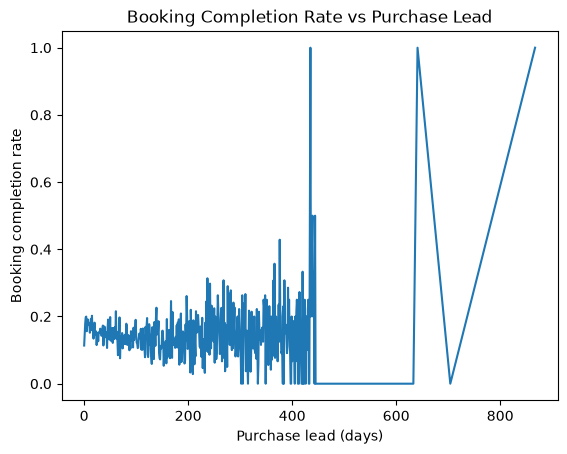

In [35]:
df.groupby("purchase_lead")["booking_complete"].mean().plot()
plt.xlabel("Purchase lead (days)")
plt.ylabel("Booking completion rate")
plt.title("Booking Completion Rate vs Purchase Lead")
plt.show()

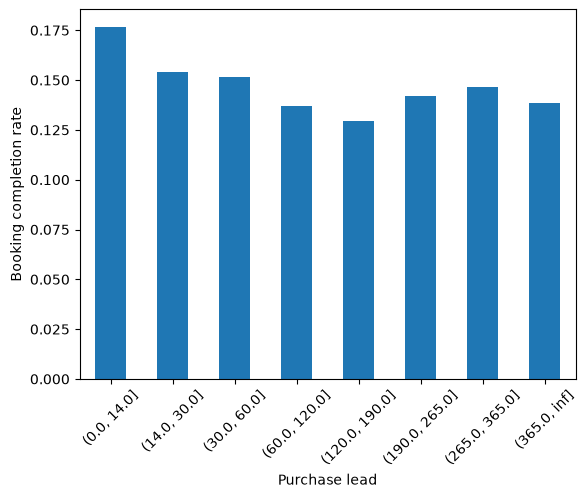

In [36]:
bins = [0, 14, 30, 60, 120, 190, 265, 365, float("inf")]

df["lead_bin"] = pd.cut(df["purchase_lead"], bins=bins)

df.groupby("lead_bin", observed=True)["booking_complete"].mean().plot(kind="bar")
plt.ylabel("Booking completion rate")
plt.xlabel("Purchase lead")
plt.xticks(rotation=45)
plt.show()

In [37]:
df["lead_bin"]

0        (190.0, 265.0]
1         (60.0, 120.0]
2        (190.0, 265.0]
3         (60.0, 120.0]
4         (60.0, 120.0]
              ...      
49995      (14.0, 30.0]
49996     (60.0, 120.0]
49997      (14.0, 30.0]
49998      (14.0, 30.0]
49999      (14.0, 30.0]
Name: lead_bin, Length: 50000, dtype: category
Categories (8, interval[float64, right]): [(0.0, 14.0] < (14.0, 30.0] < (30.0, 60.0] < (60.0, 120.0] < (120.0, 190.0] < (190.0, 265.0] < (265.0, 365.0] < (365.0, inf]]

In [38]:
# before model training
df = pd.get_dummies(df, columns = ["lead_bin"], prefix="lead_bin",dtype = np.int16, drop_first=True)

In [39]:
# ploting bar plot to check the values
# ax = df.plot.bar(x='purchase_lead', y='booking_complete', rot=0, title='Booking Complete vs Purchase Lead')

In [40]:
print(f"Unique value counts: {len(df["length_of_stay"].unique())}")
print(f"number of days spent at destination, length_of_stay : {df["length_of_stay"].value_counts()}")

Unique value counts: 335
number of days spent at destination, length_of_stay : length_of_stay
6      7757
5      7286
4      5655
3      2839
17     1849
       ... 
577       1
231       1
293       1
213       1
263       1
Name: count, Length: 335, dtype: int64


In [41]:
print(df["length_of_stay"].unique())

[ 19  20  22  31  48  33  30  25  43  24  17  34  18  37  29 155  88  27
  21  28  47  35  82  26  90  23  84  61  40  96  69  89  58  56 110 165
 111  38 207  91   1 274  44  57 106  68  87  51 196  77  41 278 108 180
  72  32  62  45  50  59 125 124  46  55  60  36  65 208 204  83  42  85
  64  86  54 238 275  39  95  70  93  49 107 121 203 188  78 209 126  80
 200 255  63  92 118  79 181  76  94 305 149 177 183 162  71 109  52 140
  66 184 152  53 291 329  75 130 142 175  73 304 186 116 101 223 415 312
 143  81 144 134 135 117 120 138 153  74 261 103 104 112 157 266  98 318
  67 273 105 148 102 119 122 603 465 409 128 233  99 113 147 127  97 170
 156 160 182 115 158   0 357 173 228 205 178 123 352 141 139 129 301 176
 332 217 358 285 163 359 348 392 179 132 431 236 353 137 146 174 224 164
 306 252 171 347 185 150 361 189 343 151 133 230 215 256 365 168 335 349
 355 331 199 254 100 321 245 350 326 351 356 360 262 364 229 193 194 131
 114 191 235 239 225 190 166 280 136 330 169 345 36

In [42]:
print(df["length_of_stay"].max())
print(df["length_of_stay"].min())

778
0


In [43]:
# bins = [0, 1, 2, 3, 4,5,6,7,10,20,30,50,150 , float("inf")] # more details for short length of stay
bins = [0, 3, 7, 14, 30, 60, 150, float("inf")]
# there is no value between 7 - 14

df["stay_bin"] = pd.cut(df["length_of_stay"], bins=bins)
count = df["stay_bin"].value_counts().sort_index()
print(count)

completion_by_bin = df.groupby("stay_bin")["booking_complete"].value_counts().unstack()

completion_by_bin.columns = ["Not Completed (0)", "Completed (1)"]
completion_by_bin["Completion Rate"] = completion_by_bin["Completed (1)"] / (completion_by_bin["Completed (1)"] + completion_by_bin["Not Completed (0)"])
completion_by_bin["Not Completion Rate"] = completion_by_bin["Not Completed (0)"] / (completion_by_bin["Completed (1)"] + completion_by_bin["Not Completed (0)"])
print(completion_by_bin)

# df.groupby("stay_bin", observed=True)["stay_bin"].value_counts().plot(kind="bar")
# plt.ylabel("Number of bookings")
# plt.xlabel("Length of stay")
# plt.xticks(rotation=45)
# plt.show()

stay_bin
(0.0, 3.0]        3966
(3.0, 7.0]       20698
(7.0, 14.0]          0
(14.0, 30.0]     14828
(30.0, 60.0]      6389
(60.0, 150.0]     3486
(150.0, inf]       624
Name: count, dtype: int64
               Not Completed (0)  Completed (1)  Completion Rate  \
stay_bin                                                           
(0.0, 3.0]                  3257            709         0.178770   
(3.0, 7.0]                 16676           4022         0.194318   
(14.0, 30.0]               13331           1497         0.100958   
(30.0, 60.0]                5738            651         0.101894   
(60.0, 150.0]               2975            511         0.146586   
(150.0, inf]                 536             88         0.141026   

               Not Completion Rate  
stay_bin                            
(0.0, 3.0]                0.821230  
(3.0, 7.0]                0.805682  
(14.0, 30.0]              0.899042  
(30.0, 60.0]              0.898106  
(60.0, 150.0]             0.853414  


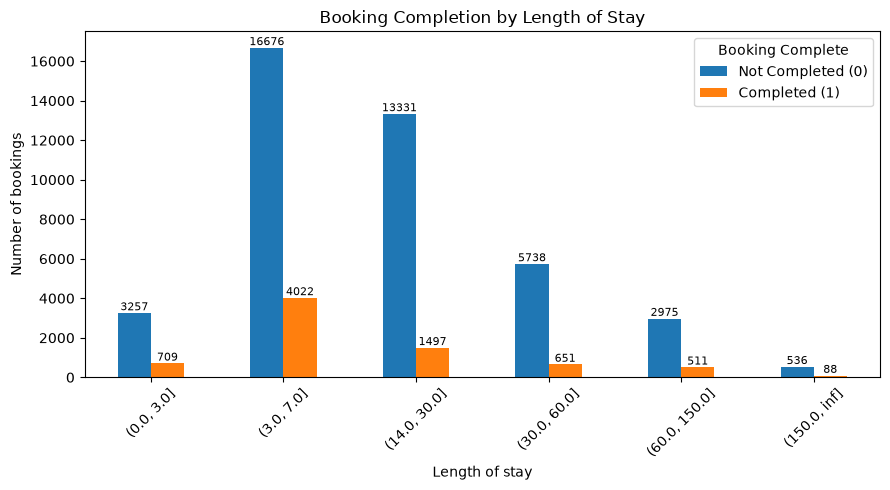

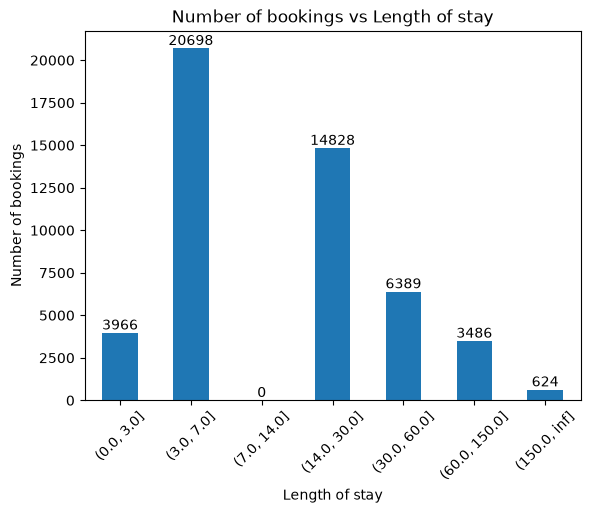

In [44]:

ax = completion_by_bin[["Not Completed (0)", "Completed (1)"]].plot(
    kind="bar", figsize=(9,5), title="Booking Completion by Length of Stay"
)

# Add value labels on each bar
for container in ax.containers:
    ax.bar_label(container, label_type="edge", fontsize=8)

plt.ylabel("Number of bookings")
plt.xlabel("Length of stay")
plt.xticks(rotation=45)
plt.legend(title="Booking Complete")
plt.tight_layout()
plt.show()

# ax = completion_by_bin.plot(kind="bar", stacked=True, figsize=(8,5),
#                               title="Booking Completion by Length of Stay")
# plt.ylabel("Number of bookings")
# plt.xlabel("Length of stay")
# plt.xticks(rotation=45)
# plt.legend(title="Booking Complete")
# plt.tight_layout()
# plt.show()
ax = count.plot(kind="bar", title="Number of bookings vs Length of stay")
for i, v in enumerate(count):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.ylabel("Number of bookings")
plt.xlabel("Length of stay")
plt.xticks(rotation=45)
plt.show()

In [45]:
# before model training
df = pd.get_dummies(df, columns = ["stay_bin"], prefix="stay_bin",dtype = np.int16)

In [46]:
print(f"hour of flight departure, flight_hour: {df["flight_hour"].value_counts()}")

hour of flight departure, flight_hour: flight_hour
8     3165
12    3163
9     3132
7     3126
11    3110
13    3101
10    3085
6     3050
5     2851
4     2843
14    2833
3     2655
2     2642
15    2234
1     2089
16    1557
0     1539
23     986
17     861
22     579
18     439
21     389
19     295
20     276
Name: count, dtype: int64


In [47]:
def get_time_of_day(hour):
    if hour < 6:
        return "Night"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"

df["flight_time_of_day"] = df["flight_hour"].apply(get_time_of_day)

# before model training
# df = pd.get_dummies(df, columns=["flight_time_of_day"], drop_first=True)

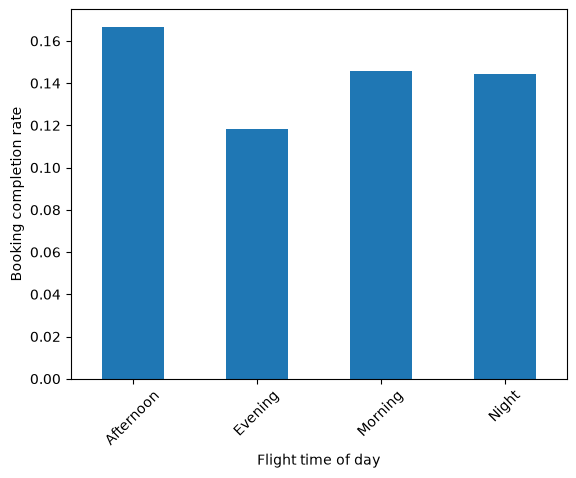

In [48]:
# bins = [0, 14, 30, 60, 120, 190, 265, 365, float("inf")]

# df["lead_bin"] = pd.cut(df["purchase_lead"], bins=bins)

df.groupby("flight_time_of_day", observed=True)["booking_complete"].mean().plot(kind="bar")
plt.ylabel("Booking completion rate")
plt.xlabel("Flight time of day")
plt.xticks(rotation=45)
plt.show()

In [49]:
print(f"day of week of flight departure, flight_day: {df["flight_day"].value_counts()}")

day of week of flight departure, flight_day: flight_day
Mon    8102
Wed    7674
Tue    7673
Thu    7424
Fri    6761
Sun    6554
Sat    5812
Name: count, dtype: int64


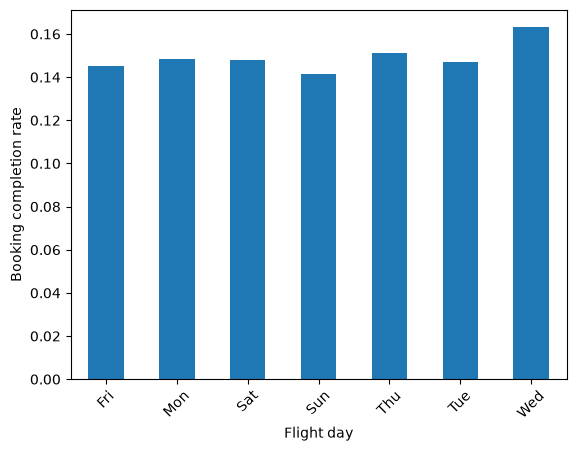

In [50]:
df.groupby("flight_day", observed=True)["booking_complete"].mean().plot(kind="bar")
plt.ylabel("Booking completion rate")
plt.xlabel("Flight day")
plt.xticks(rotation=45)
plt.show()

In [51]:

print(f"Unique value counts: {len(df["route"].unique())}")
print(f"origin -> destination flight route, route: {df["route"].value_counts()}")

Unique value counts: 799
origin -> destination flight route, route: route
AKLKUL    2680
PENTPE     924
MELSGN     842
ICNSIN     801
DMKKIX     744
          ... 
HKTJED       1
JEDMFM       1
KBRWUH       1
KTMTWU       1
MRUXIY       1
Name: count, Length: 799, dtype: int64


In [52]:
print(df["route"].value_counts().max())
print(df["route"].value_counts().min())

2680
1


In [53]:
cardinality = df["route"].nunique()
print(f"Cardinality of the route column: {cardinality}")

Cardinality of the route column: 799


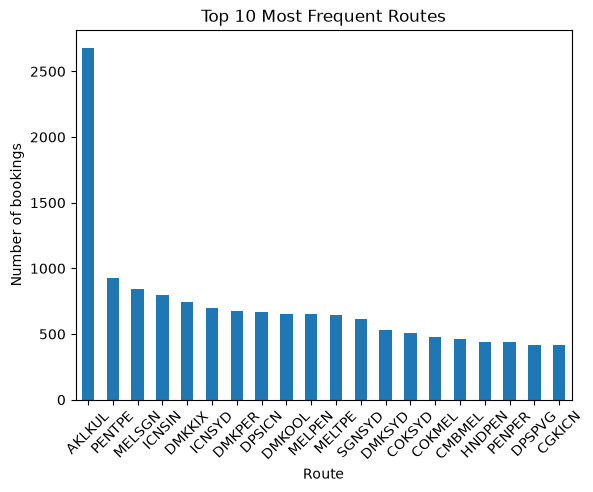

In [54]:
df["route"].value_counts().head(20).plot(kind="bar")
plt.xlabel("Route")
plt.ylabel("Number of bookings")
plt.title("Top 10 Most Frequent Routes")
plt.xticks(rotation=45)
plt.show()

In [55]:
route_counts = df["route"].value_counts()
df["route_frequency"] = df["route"].map(route_counts) # # counts the each route, how many time each route is repeated in the datase

In [56]:
route_counts # counts the each route, how many time each route is repeated in the dataset

route
AKLKUL    2680
PENTPE     924
MELSGN     842
ICNSIN     801
DMKKIX     744
          ... 
HKTJED       1
JEDMFM       1
KBRWUH       1
KTMTWU       1
MRUXIY       1
Name: count, Length: 799, dtype: int64

##### Which route_frequency has the best booking completion rate (top 15)

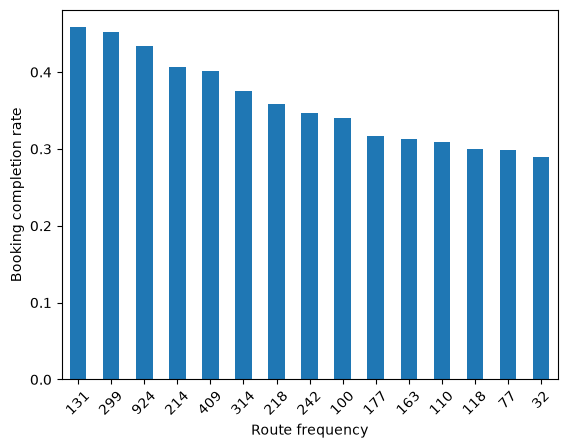

In [57]:
rate = df.groupby(["route_frequency"], observed=True)["booking_complete"].mean() #.plot(kind="bar")
rate.sort_values(ascending=False).head(15).plot(kind = "bar")
plt.ylabel("Booking completion rate")
plt.xlabel("Route frequency")
plt.xticks(rotation=45)
plt.show()

In [58]:
print(rate.sort_values(ascending=False).head(20))

route_frequency
131    0.458015
299    0.451505
924    0.433983
214    0.406542
409    0.400978
314    0.375796
218    0.357798
242    0.347107
100    0.340000
177    0.316384
163    0.312883
110    0.309091
118    0.299435
77     0.298701
32     0.289062
43     0.286822
275    0.280000
115    0.278261
350    0.271429
389    0.269923
Name: booking_complete, dtype: float64


In [59]:
print(f"Unique value counts: {len(df["booking_origin"].unique())}")
print(f"country from where booking was made, booking_origin : {df["booking_origin"].value_counts()}")

Unique value counts: 104
country from where booking was made, booking_origin : booking_origin
Australia               17872
Malaysia                 7174
South Korea              4559
Japan                    3885
China                    3387
                        ...  
Ghana                       1
Gibraltar                   1
Guatemala                   1
Algeria                     1
Svalbard & Jan Mayen        1
Name: count, Length: 104, dtype: int64


In [60]:
df["booking_origin"].value_counts().unique()

array([17872,  7174,  4559,  3885,  3387,  2369,  2077,  2030,  1270,
        1074,  1044,   456,   388,   304,   295,   266,   173,   167,
         132,    84,    73,    59,    58,    57,    51,    46,    44,
          42,    40,    36,    32,    27,    25,    18,    17,    15,
          14,    12,     9,     8,     7,     6,     5,     4,     3,
           2,     1])

booking_origin
Australia               17872
Malaysia                 7174
South Korea              4559
Japan                    3885
China                    3387
                        ...  
Ghana                       1
Gibraltar                   1
Guatemala                   1
Algeria                     1
Svalbard & Jan Mayen        1
Name: count, Length: 104, dtype: int64

booking_origin
(not set)                  84
Afghanistan                 1
Algeria                     1
Argentina                   6
Australia               17872
                        ...  
United Arab Emirates       42
United Kingdom            173
United States             456
Vanuatu                     1
Vietnam                   388
Name: count, Length: 104, dtype: int64
origin_frequency_bin
(0.0, 100.0]          0.133581
(100.0, 300.0]        0.238141
(300.0, 800.0]        0.255226
(800.0, 1200.0]       0.166667
(1200.0, 1800.0]      0.103150
(1800.0, 2500.0]      0.202131
(2500.0, 3500.0]      0.204901
(3500.0, 5000.0]      0.111322
(7000.0, 10000.0]     0.344020
(15000.0, 20000.0]    0.050358
Name: booking_complete, dtype: float64


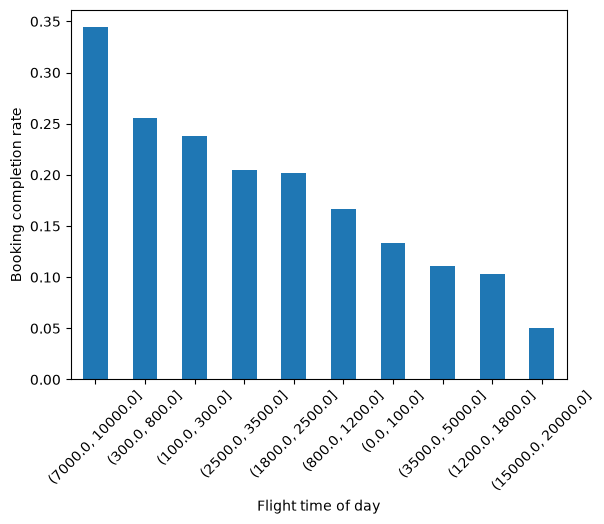

In [68]:
bins = [0, 100, 300, 800, 1200, 1800, 2500, 3500, 5000, 7000, 10000, 15000, 20000,  float("inf")]

# I want to groupe by booking origin for count of bookings given in the bin in x-axis and in y-axis booking completion rate for each bins
# df["lead_bin"] = pd.cut(df["purchase_lead"], bins=bins)
booking_counts = df["booking_origin"].value_counts().sort_index()
print(booking_counts)

df["origin_frequency_bin"] = pd.cut(df["booking_origin"].map(booking_counts), bins = bins)

freq = df.groupby("origin_frequency_bin", observed=True)["booking_complete"].mean()#.plot(kind="bar")
print(freq)
freq.sort_values(ascending=False).plot(kind="bar")
plt.ylabel("Booking completion rate")
plt.xlabel("Flight time of day")
plt.xticks(rotation=45)
plt.show()

In [11]:
print(f"if the customer wanted extra baggage in the booking, wants_extra_baggage: {df["wants_extra_baggage"].value_counts()}")
print(f"if the customer wanted a preferred seat in the booking, wants_preferred_seat: {df["wants_preferred_seat"].value_counts()}")
print(f"if the customer wanted in-flight meals, wants_in_flight_meals: {df["wants_in_flight_meals"].value_counts()}")

if the customer wanted extra baggage in the booking, wants_extra_baggage: wants_extra_baggage
1    33439
0    16561
Name: count, dtype: int64
if the customer wanted a preferred seat in the booking, wants_preferred_seat: wants_preferred_seat
0    35152
1    14848
Name: count, dtype: int64
if the customer wanted in-flight meals, wants_in_flight_meals: wants_in_flight_meals
0    28643
1    21357
Name: count, dtype: int64


In [29]:
df["total_extras"] = df["wants_extra_baggage"] + df["wants_preferred_seat"] + df["wants_in_flight_meals"]

In [19]:
print(f"total duration of flight (in hours), flight_duration: {df["flight_duration"].value_counts()}")

total duration of flight (in hours), flight_duration: flight_duration
8.83    14520
8.58     6965
5.62     5524
6.62     4721
7.00     3374
7.57     2835
4.67     2743
6.42     1737
5.33     1554
4.75     1255
6.33     1190
8.67      807
5.52      667
5.07      512
4.72      502
8.15      311
5.00      241
7.42      224
4.83      156
5.13      125
9.50       37
Name: count, dtype: int64


In [ ]:

print(f"Booking Complete, booking_complete: {df["booking_complete"].value_counts()}")

Booking Complete, booking_complete: booking_complete
0    42522
1     7478
Name: count, dtype: int64


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  str    
 2   trip_type              50000 non-null  str    
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  str    
 7   route                  50000 non-null  str    
 8   booking_origin         50000 non-null  str    
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 5.3 MB


The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [4]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [5]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [6]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [7]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

### frequency encoding

In [ ]:
df["route"]